In [ ]:
# Count number of parameters in model 
import torch

ckpt_path = "/work3/s185395/yaib_logs/eicu_mimic/LOS/SSL_BAT_tuned_eicu_mimic/2025-11-20T21-46-16/repetition_0/fold_0/model.ckpt"

def count_params_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    
    # Extract the state_dict
    if "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    else:
        state_dict = ckpt

    # Clean keys if they have Lightning prefixes
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace("model.", "").replace("module.", "")
        new_state_dict[new_key] = v
    state_dict = new_state_dict

    # Count parameters
    total_params = sum(v.numel() for v in state_dict.values())
    return total_params

total_params = count_params_from_ckpt(ckpt_path)
print(f"Total parameters in checkpoint: {total_params:,}")


In [ ]:
# Fine-tuning and from scratch results for mimic-III as fine-tuning/training from scratch dataset 
json_mimic_bat = """
{
  "model": "SL_BAT",
  "dataset": "mimic",
  "type": "subset",
  "sample_sizes": {
    "100": {"test/AUC": "60.38 ± 0.64", "test/PR": "18.27 ± 2.19", "test/loss": "35.56 ± 0.02"},
    "500": {"test/AUC": "60.70 ± 0.94", "test/PR": "18.05 ± 0.96", "test/loss": "36.43 ± 0.12"},
    "1000": {"test/AUC": "75.72 ± 0.98", "test/PR": "32.12 ± 4.04", "test/loss": "31.82 ± 0.55"},
    "2000": {"test/AUC": "77.88 ± 0.30", "test/PR": "37.51 ± 1.55", "test/loss": "30.83 ± 0.28"},
    "3000": {"test/AUC": "79.05 ± 0.67", "test/PR": "39.15 ± 1.54", "test/loss": "31.32 ± 0.74"},
    "5000": {"test/AUC": "80.29 ± 0.36", "test/PR": "41.36 ± 0.91", "test/loss": "29.88 ± 0.53"},
    "7000": {"test/AUC": "81.25 ± 0.22", "test/PR": "43.05 ± 0.88", "test/loss": "29.48 ± 0.73"},
    "9000": {"test/AUC": "81.99 ± 0.44", "test/PR": "44.42 ± 0.78", "test/loss": "28.89 ± 0.78"},
    "9506": {"test/AUC": "82.49 ± 0.00", "test/PR": "45.05 ± 0.00", "test/loss": "28.68 ± 0.00"}
  }
}
"""

json_mimic_trans = """
{
  "model": "SL_Transformer",
  "dataset": "mimic",
  "type": "subset",
  "sample_sizes": {
    "100": {"test/AUC": "55.89 ± 1.18", "test/PR": "15.39 ± 0.96", "test/loss": "330.25 ± 253.32"},
    "500": {"test/AUC": "60.28 ± 3.01", "test/PR": "18.95 ± 1.43", "test/loss": "144.00 ± 223.62"},
    "1000": {"test/AUC": "64.84 ± 6.97", "test/PR": "22.51 ± 4.44", "test/loss": "54.28 ± 25.58"},
    "2000": {"test/AUC": "69.97 ± 0.73", "test/PR": "25.26 ± 1.33", "test/loss": "68.44 ± 3.49"},
    "3000": {"test/AUC": "71.27 ± 0.44", "test/PR": "26.05 ± 1.51", "test/loss": "67.82 ± 1.82"},
    "5000": {"test/AUC": "71.32 ± 0.84", "test/PR": "25.72 ± 0.89", "test/loss": "71.21 ± 5.45"},
    "7000": {"test/AUC": "72.44 ± 0.30", "test/PR": "26.44 ± 0.32", "test/loss": "67.36 ± 3.17"},
    "9000": {"test/AUC": "72.57 ± 0.33", "test/PR": "26.33 ± 0.26", "test/loss": "70.05 ± 4.35"},
    "9506": {"test/AUC": "72.91 ± 0.00", "test/PR": "26.61 ± 0.00", "test/loss": "68.40 ± 0.00"}
  }
}
"""

json_mimic_ssl_bat_head = """
{
  "model": "SSL_BAT_head",
  "dataset": "mimic",
  "type": "subset",
  "sample_sizes": {
    "100": {"test/AUC": "72.17 ± 4.98", "test/PR": "30.95 ± 5.03"},
    "500": {"test/AUC": "74.34 ± 0.41", "test/PR": "35.94 ± 0.92"},
    "1000": {"test/AUC": "73.81 ± 0.81", "test/PR": "36.50 ± 0.69"},
    "2000": {"test/AUC": "75.74 ± 1.44", "test/PR": "37.37 ± 1.75"},
    "3000": {"test/AUC": "76.85 ± 0.98", "test/PR": "38.55 ± 1.17"},
    "5000": {"test/AUC": "77.90 ± 1.19", "test/PR": "39.83 ± 0.90"},
    "7000": {"test/AUC": "78.28 ± 1.19", "test/PR": "40.49 ± 1.05"},
    "9000": {"test/AUC": "78.53 ± 0.67", "test/PR": "40.68 ± 0.99"},
    "9506": {"test/AUC": "79.76 ± 0.00", "test/PR": "41.93 ± 0.00"}
  }
}
"""

json_mimic_ssl_bat_full = """
{
  "model": "SSL_BAT_full",
  "dataset": "mimic",
  "type": "subset",
  "sample_sizes": {
    "100": {"test/AUC": "74.38 ± 1.76", "test/PR": "31.07 ± 2.59"},
    "500": {"test/AUC": "77.38 ± 0.41", "test/PR": "34.74 ± 0.96"},
    "1000": {"test/AUC": "78.93 ± 1.05", "test/PR": "38.02 ± 1.79"},
    "2000": {"test/AUC": "80.34 ± 0.89", "test/PR": "39.57 ± 1.59"},
    "3000": {"test/AUC": "80.96 ± 0.55", "test/PR": "40.48 ± 1.33"},
    "5000": {"test/AUC": "81.83 ± 0.69", "test/PR": "41.34 ± 0.88"},
    "7000": {"test/AUC": "82.05 ± 0.49", "test/PR": "41.58 ± 1.05"},
    "9000": {"test/AUC": "82.69 ± 0.41", "test/PR": "42.90 ± 0.50"},
    "9506": {"test/AUC": "82.66 ± 0.00", "test/PR": "43.48 ± 0.00"}
  }
}
"""


In [ ]:
def plot_with_shading(x, mean, std, label, color, linestyle, fontsize=14):
    plt.plot(x, mean, label=label, color=color, linestyle=linestyle)
    plt.fill_between(x, mean - std, mean + std, color=color, alpha=0.2)


def plot_dataset(dataset_name):
    # Load core models
    json_bat = globals()[f"json_{dataset_name}_bat"]
    json_trans = globals()[f"json_{dataset_name}_trans"]
    json_head = globals()[f"json_{dataset_name}_ssl_bat_head"]

    bat = json.loads(json_bat)
    trans = json.loads(json_trans)
    head = json.loads(json_head)

    bat_sizes, bat_auc, bat_auc_std, bat_pr, bat_pr_std = extract_metrics(bat)
    trans_sizes, trans_auc, trans_auc_std, trans_pr, trans_pr_std = extract_metrics(trans)
    head_sizes, head_auc, head_auc_std, head_pr, head_pr_std = extract_metrics(head)

    # Try loading SSL_BAT_full if present
    full_present = False
    try:
        json_full = globals()[f"json_{dataset_name}_ssl_bat_full"]
        full = json.loads(json_full)
        full_sizes, full_auc, full_auc_std, full_pr, full_pr_std = extract_metrics(full)
        full_present = True
    except KeyError:
        pass

    # ---------------- Updated plot_settings ----------------
    plot_settings = {
        "BAT (Scratch)": {"color": "#D4A017", "linestyle": "-."},          # dark yellow
        "Transformer (Scratch)": {"color": "purple", "linestyle": ":"},    # dotted
        "BAT (Fine-tuned head)": {"color": "mediumblue", "linestyle": "--"},  # darker king's blue
        "BAT (Fine-tuned full)": {"color": "darkgreen", "linestyle": "-"}  # solid
    }

    # Font size for all text
    fontsize = 16

    # ---------------- AUC-ROC Plot ----------------
    plt.figure(figsize=(8,5))
    if full_present:
        plot_with_shading(full_sizes, full_auc, full_auc_std, "BAT (Fine-tuned full)",
                          plot_settings["BAT (Fine-tuned full)"]["color"],
                          plot_settings["BAT (Fine-tuned full)"]["linestyle"])
    plot_with_shading(head_sizes, head_auc, head_auc_std, "BAT (Fine-tuned head)",
                      plot_settings["BAT (Fine-tuned head)"]["color"],
                      plot_settings["BAT (Fine-tuned head)"]["linestyle"])
    plot_with_shading(bat_sizes, bat_auc, bat_auc_std, "BAT (Scratch)",
                      plot_settings["BAT (Scratch)"]["color"],
                      plot_settings["BAT (Scratch)"]["linestyle"])
    plot_with_shading(trans_sizes, trans_auc, trans_auc_std, "Transformer (Scratch)",
                      plot_settings["Transformer (Scratch)"]["color"],
                      plot_settings["Transformer (Scratch)"]["linestyle"])

    plt.title("Mortality AUC-ROC", fontsize=fontsize + 2)
    plt.xlabel("Number of MIMIC-IV training patient stays", fontsize=fontsize)
    plt.ylabel("AUC-ROC", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.grid(True)
    plt.legend(fontsize=fontsize)
    plt.tight_layout()
    plt.show()

    # ---------------- AUC-PR Plot ----------------
    plt.figure(figsize=(8,5))
    if full_present:
        plot_with_shading(full_sizes, full_pr, full_pr_std, "BAT (Fine-tuned full)",
                          plot_settings["BAT (Fine-tuned full)"]["color"],
                          plot_settings["BAT (Fine-tuned full)"]["linestyle"])
    plot_with_shading(head_sizes, head_pr, head_pr_std, "BAT (Fine-tuned head)",
                      plot_settings["BAT (Fine-tuned head)"]["color"],
                      plot_settings["BAT (Fine-tuned head)"]["linestyle"])
    plot_with_shading(bat_sizes, bat_pr, bat_pr_std, "BAT (Scratch)",
                      plot_settings["BAT (Scratch)"]["color"],
                      plot_settings["BAT (Scratch)"]["linestyle"])
    plot_with_shading(trans_sizes, trans_pr, trans_pr_std, "Transformer (Scratch)",
                      plot_settings["Transformer (Scratch)"]["color"],
                      plot_settings["Transformer (Scratch)"]["linestyle"])

    # Add horizontal dashed grey line at y=11.9
    plt.axhline(y=11.9, color='grey', linestyle='--', alpha=0.5, linewidth=1.5)

    plt.title("Mortality AUC-PR", fontsize=fontsize + 2)
    plt.xlabel("Number of MIMIC-IV training patient stays", fontsize=fontsize)
    plt.ylabel("AUC-PR", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.grid(True)
    plt.legend(fontsize=fontsize)
    plt.tight_layout()
    plt.show()


In [8]:
import numpy as np
import matplotlib.pyplot as plt


def extract_metrics(json_obj):
    sizes = []
    auc_mean = []
    auc_std = []
    pr_mean = []
    pr_std = []

    for size_str, metrics in sorted(json_obj['sample_sizes'].items(), key=lambda x: int(x[0])):
        sizes.append(int(size_str))

        # Parse AUC
        auc_val = metrics["test/AUC"]
        if "±" in auc_val:
            mean, std = map(float, auc_val.split("±"))
        else:
            mean, std = float(auc_val), 0.0
        auc_mean.append(mean)
        auc_std.append(std)

        # Parse PR
        pr_val = metrics["test/PR"]
        if "±" in pr_val:
            mean, std = map(float, pr_val.split("±"))
        else:
            mean, std = float(pr_val), 0.0
        pr_mean.append(mean)
        pr_std.append(std)

    return np.array(sizes), np.array(auc_mean), np.array(auc_std), np.array(pr_mean), np.array(pr_std)


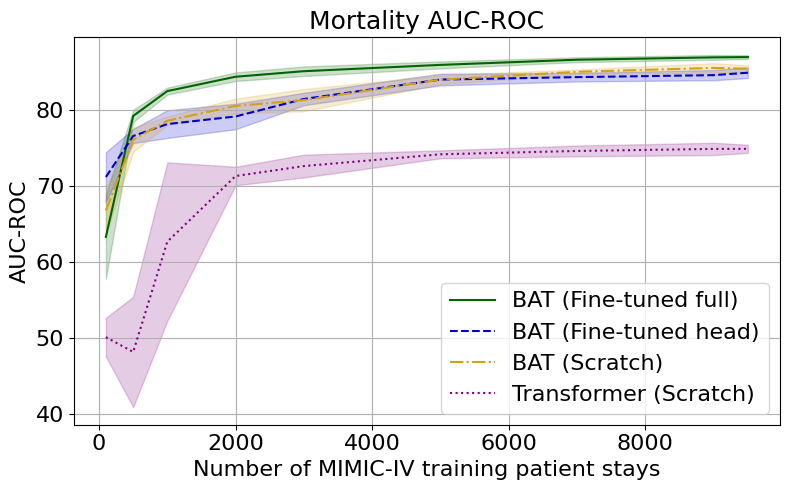

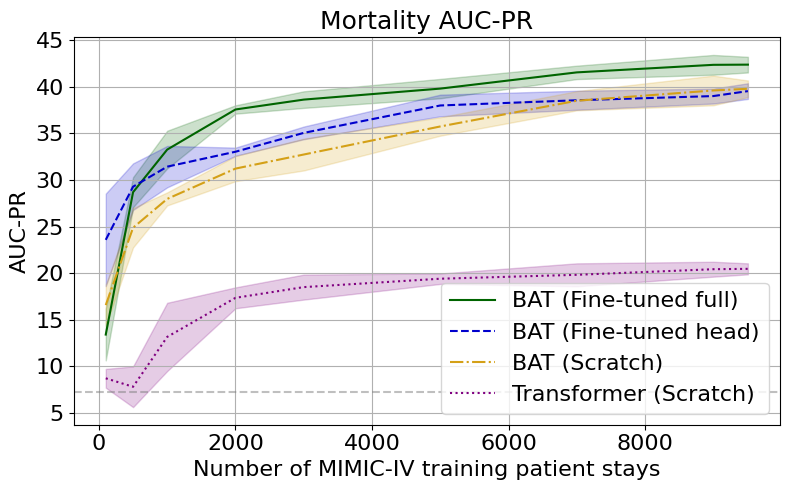

In [ ]:
import json
plot_dataset("mimic")
